# 0. Import library and load dat

In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
sns.set(style="whitegrid")
import re

In [2]:
df = pd.read_json("../../Data/Shopee/Cosmetic_Shopee_Data.json")

# 1. Dataset overview

## 1.1 Basic information

We first tak a look at the dataframe's first 5 rows and some of its attributes:

In [3]:
df.head()

,Platform,Main_Category,Sub_Category,ID,Shop_ID,Name,Brand,Price,Original_Price,Discount_Percent,...,Reviews,Monthly_Sold,Total_Sold,Liked_Count,Shop_Location,Is_Mall,Is_Verified,Is_FreeShip,Is_Ads,Created_At_Days
0,Shopee,Beauty_Devices,lược điện,42327913165,1681939005,Phong Cách Mới Sạc Không Dây Di Động LCD Tóc T...,No Brand,139523,233123,40.2,...,0,1,3,0,Nước ngoài,0,0,0,0,85.4
1,Shopee,Beauty_Devices,lược điện,42417976686,1620193358,Lược Điện Chải Tóc Không Dây Ion Âm JC-888 See...,SeeMee,183000,350000,47.7,...,270,2000,2000,4,TP. Hồ Chí Minh,0,0,0,0,210.5
2,Shopee,Beauty_Devices,lược điện,47357926177,1506174776,Lược Điện Uốn Mái Mini KOIZUMI Không Dây Tạo K...,KOIZUMI,908500,1485000,38.8,...,52,1,463,2462,Hà Nội,0,1,0,0,180.3
3,Shopee,Beauty_Devices,lược điện,51102137858,1634218010,Lược Điện Chải Tóc Ion Âm Lược Duỗi Tóc Không...,No Brand,195000,250000,22.0,...,171,1000,1000,23,Hà Nội,0,0,0,0,131.2
4,Shopee,Beauty_Devices,lược điện,55400131427,1252295440,Lược Điện Không Dây SeeMee Chăm Sóc Tóc Suôn M...,No Brand,189000,509000,62.9,...,189,1000,1000,27,TP. Hồ Chí Minh,0,1,0,0,163.5


- **Number of rows**: The dataset contains **45104 rows** (index from 0 to 45103)
- **Number of columns**: The dataset contains **21 columns**
- **What does each row represent for?**: Each row corresponding to one cosmetic product sold in Shopee Viet Nam. Each product is identified by its ID and Shop's ID while the remaining columns describe the product's attribute such price, discount, ratings, reviews, etc. 
- **Overall dataset size**: The dataframe's memory footprint is approximately **30 MB**

In [4]:
df.info()
print("Approx. size (MB):", df.memory_usage(deep=True).sum()/(1024**2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45104 entries, 0 to 45103
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Platform          45104 non-null  object 
 1   Main_Category     45104 non-null  object 
 2   Sub_Category      45104 non-null  object 
 3   ID                45104 non-null  int64  
 4   Shop_ID           45104 non-null  int64  
 5   Name              45104 non-null  object 
 6   Brand             45104 non-null  object 
 7   Price             45104 non-null  int64  
 8   Original_Price    45104 non-null  int64  
 9   Discount_Percent  45104 non-null  float64
 10  Rating            45104 non-null  float64
 11  Reviews           45104 non-null  int64  
 12  Monthly_Sold      45104 non-null  int64  
 13  Total_Sold        45104 non-null  int64  
 14  Liked_Count       45104 non-null  int64  
 15  Shop_Location     45104 non-null  object 
 16  Is_Mall           45104 non-null  int64 

## 1.2 Data Integrity

Fortunately, our crawled data is clean in overall. There are no duplicated rows as well as empty ones. However, there would be data inconsistency which we will check later in the next sections. 

In [36]:
temp = df.copy()
temp = temp.apply(lambda x: x.astype(str).str.strip())
temp.replace("", None, inplace=True)

dup_full = temp.duplicated().sum()
empty_rows = temp.isna().all(axis=1).sum()

print("Duplicated rows:", dup_full)
print("Fully empty rows:", empty_rows)

Duplicated rows: 0
Fully empty rows: 0


## 1.3 Meaning/Definition of each column

There are 21 columns in total in the datasets, this table includes detail information and meaning of each:

| Column               | Current Dtype | Example Value     | Target Dtype | Meaning / Description                            |
| :------------------- | :------------ | :---------------- | :----------- | :----------------------------------------------- |
| **Platform**         | Object        | `Shopee`          | Category     | E-commerce platform where the product is listed  |
| **Main_Category**    | Object        | `Beauty`          | Category     | Main product category (high-level grouping)      |
| **Sub_Category**     | Object        | `Skincare`        | Category     | Detailed product category                        |
| **ID**               | Int64         | `123456789`       | Int64        | Unique product identifier                        |
| **Shop_ID**          | Int64         | `987654321`       | Int64        | Unique shop identifier                           |
| **Name**             | Object        | `Serum Vitamin C` | Object       | Product name/title                               |
| **Brand**            | Object        | `L'Oreal`         | Category     | Brand of the product                             |
| **Price**            | Int64         | `120000`          | Float / Int  | Current selling price (VND)                      |
| **Original_Price**   | Int64         | `150000`          | Float / Int  | Original price before discount                   |
| **Discount_Percent** | Float64       | `20.0`            | Float64      | Discount percentage applied                      |
| **Rating**           | Float64       | `4.8`             | Float64      | Average user rating (0–5)                        |
| **Reviews**          | Int64         | `1500`            | Int64        | Number of user reviews                           |
| **Monthly_Sold**     | Int64         | `300`             | Int64        | Estimated number of units sold per month         |
| **Total_Sold**       | Int64         | `5000`            | Int64        | Total units sold since listing                   |
| **Liked_Count**      | Int64         | `200`             | Int64        | Number of users who liked the product            |
| **Shop_Location**    | Object        | `Hanoi`           | Category     | Location of the shop                             |
| **Is_Mall**          | Int64         | `1`               | Boolean      | Whether the shop is Shopee Mall (official store) |
| **Is_Verified**      | Int64         | `1`               | Boolean      | Whether the shop is verified                     |
| **Is_FreeShip**      | Int64         | `0`               | Boolean      | Whether product has free shipping                |
| **Is_Ads**           | Int64         | `1`               | Boolean      | Whether product is advertised                    |
| **Created_At_Days**  | Float64       | `365.0`           | Int / Float  | Number of days since product was listed          |


# 2. Numerical Column Analysis

| Column               | Current Dtype | Example Value | Target Dtype | Meaning / Description          |
| :------------------- | :------------ | :------------ | :----------- | :----------------------------- |
| **Price**            | Int64         | `120000`      | Float / Int  | Current selling price (VND)    |
| **Original_Price**   | Int64         | `150000`      | Float / Int  | Original price before discount |
| **Discount_Percent** | Float64       | `20.0`        | Float64      | Discount percentage applied    |
| **Rating**           | Float64       | `4.8`         | Float64      | Average user rating (0–5)      |
| **Reviews**          | Int64         | `1500`        | Int64        | Number of user reviews         |
| **Monthly_Sold**     | Int64         | `300`         | Int64        | Estimated units sold per month |
| **Total_Sold**       | Int64         | `5000`        | Int64        | Total units sold               |
| **Liked_Count**      | Int64         | `200`         | Int64        | Number of likes                |
| **Created_At_Days**  | Float64       | `365.0`       | Int / Float  | Days since product was listed  |


## 2.1 Overview statistic

We then create the seperated dataframe of numerical attributes:

In [7]:
numerical_cols = [
    'Price', 'Original_Price', 'Discount_Percent', 'Rating',
    'Reviews', 'Monthly_Sold', 'Total_Sold', 'Liked_Count',
    'Created_At_Days'
]

df_num = df[numerical_cols]

Let's take a look at the statistical description of numerical data:

In [8]:
df_num.describe()

,Price,Original_Price,Discount_Percent,Rating,Reviews,Monthly_Sold,Total_Sold,Liked_Count,Created_At_Days
count,4.510400e+04,4.510400e+04,45104.000000,45104.000000,45104.000000,4.510400e+04,4.510400e+04,45104.000000,45104.000000
mean,3.389942e+05,4.187182e+05,19.502454,3.979676,971.010531,6.272849e+03,1.119729e+04,781.609325,653.848144
std,2.877753e+06,3.224564e+06,19.008361,1.900114,6514.702143,9.198780e+04,1.044560e+05,4170.237406,661.831277
min,1.000000e+03,1.000000e+03,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,5.700000e+04,7.000000e+04,0.000000,4.712863,2.000000,2.000000e+00,1.900000e+01,1.000000,131.100000
50%,1.131000e+05,1.500000e+05,16.700000,4.907715,63.000000,4.800000e+01,4.930000e+02,16.000000,441.200000
75%,2.100000e+05,2.890000e+05,34.700000,4.961538,434.000000,7.900000e+02,3.000000e+03,154.000000,965.200000
max,1.200000e+08,1.200000e+08,99.100000,5.000000,804240.000000,1.000000e+07,1.000000e+07,188903.000000,3882.100000


## 2.2 Range & Outliers


Outliers were identified using the Interquartile Range (IQR) method for all numerical variables. The results show that most variables exhibit a significant proportion of outliers, indicating highly skewed distributions.

- **``Price`` (8.34%)** and **``Original_Price`` (7.43%)** have a moderate proportion of outliers. This suggests the presence of high-priced products, likely representing premium or luxury items in the dataset.

- **``Discount_Percent`` (0.23%)** has a very low percentage of outliers, indicating that discount values are relatively consistent and well-bounded across products.

- **``Rating`` (20.30%)** shows a very high proportion of outliers. This is likely due to the distribution being heavily concentrated near the upper bound (close to 5), making lower ratings appear as outliers under the IQR method. This reflects a common bias in e-commerce platforms where most products receive high ratings.

- **``Reviews`` (13.21%)**, **``Monthly_Sold`` (17.18%)**, **``Total_Sold`` (15.34%)**, and **``Liked_Count`` (17.11%)** all have a high percentage of outliers. These variables are strongly right-skewed, indicating that a small number of products (e.g., popular or viral items) dominate in terms of engagement and sales.

- **``Created_At_Days`` (3.30%)** has a relatively low proportion of outliers, suggesting that product listing durations are more evenly distributed compared to other variables.

In [23]:
import pandas as pd

def detect_outliers_iqr_df(df):
    results = []

    for col in df.columns:
        data = df[col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data < lower) | (data > upper)]

        results.append({
            "Column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outliers_Count": len(outliers),
            "Outliers_Percent": (len(outliers) / len(data) * 100)
        })
    return pd.DataFrame(results)

outlier_df = detect_outliers_iqr_df(df_num)
outlier_df

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers_Count,Outliers_Percent
0,Price,57000.000000,210000.000000,153000.000000,-172500.00000,439500.000000,3763,8.342941
1,Original_Price,70000.000000,289000.000000,219000.000000,-258500.00000,617500.000000,3349,7.425062
2,Discount_Percent,0.000000,34.700000,34.700000,-52.05000,86.750000,102,0.226144
3,Rating,4.712863,4.961538,0.248676,4.33985,5.334552,9155,20.297535
4,Reviews,2.000000,434.000000,432.000000,-646.00000,1082.000000,5959,13.211689
5,Monthly_Sold,2.000000,790.000000,788.000000,-1180.00000,1972.000000,7750,17.182512
6,Total_Sold,19.000000,3000.000000,2981.000000,-4452.50000,7471.500000,6918,15.337886
7,Liked_Count,1.000000,154.000000,153.000000,-228.50000,383.500000,7719,17.113781
8,Created_At_Days,131.100000,965.200000,834.100000,-1120.05000,2216.350000,1487,3.296825


Without the outliers, we take a look at the every attributes's boxplots:

-**Positive Skew (Right-Skewed)**: Most variables (``Price``, ``Original_Price``, ``Discount_Percent``, ``Reviews``, ``Monthly_Sold``, ``Total_Sold``, ``Liked_Count``, ``Created_At_Days``) show a concentration of data at lower values with a long tail toward the higher end.

-**Popularity & Sales:** Metrics like ``Reviews``, ``Monthly_Sold``, and ``Liked_Count`` are heavily skewed. This indicates that while most products have low engagement, a small group of "bestsellers" performs significantly higher than the average.

-**Negative Skew (Left-Skewed)**: ``Rating`` is the only exception. Most products have very high scores (median ~4.85), with a tail extending toward lower ratings.

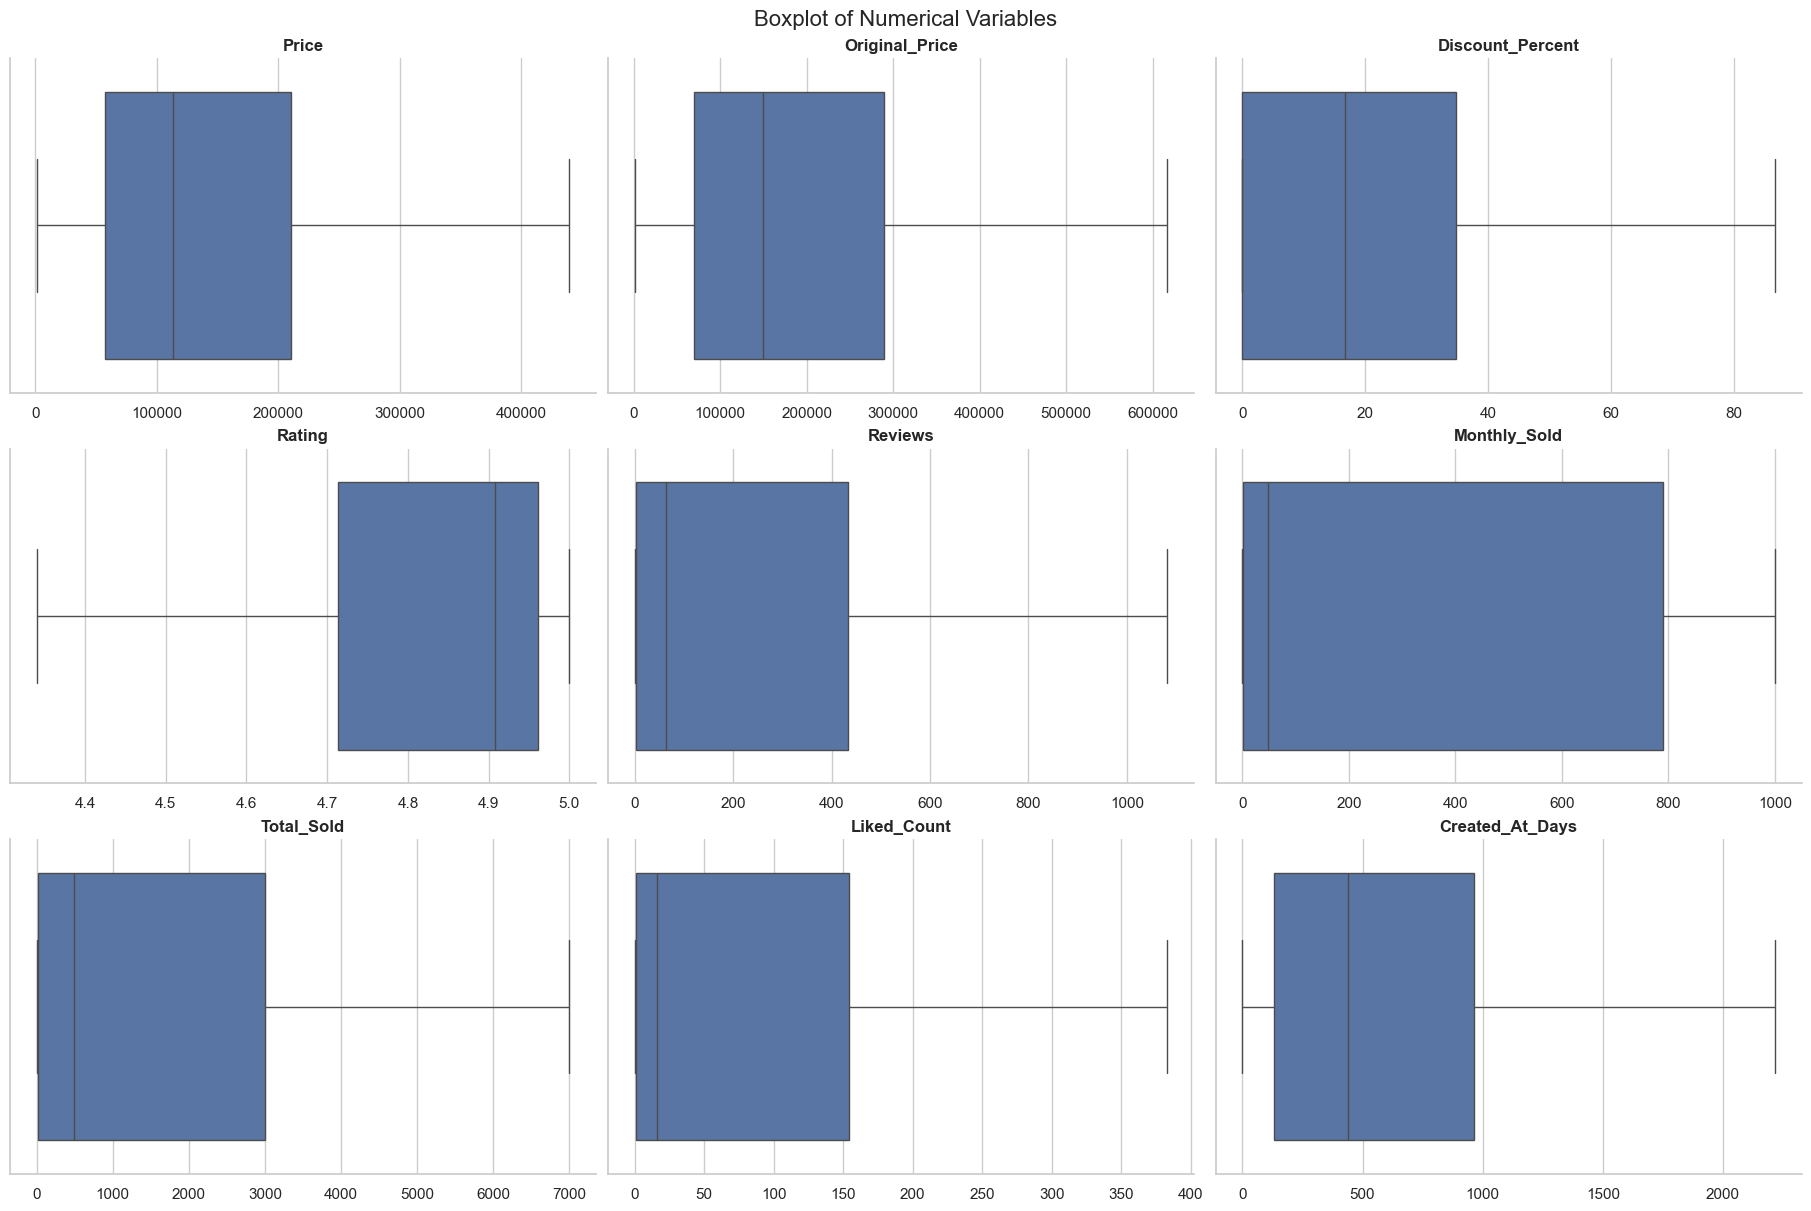

In [19]:
tmp = df_num.copy()

fig, axes = plt.subplots(3, 3, figsize=(18, 12), constrained_layout=True)
fig.suptitle('Boxplot of Numerical Variables', fontsize=16)

for ax, col in zip(axes.flatten(), tmp.columns):
    sns.boxplot(x=tmp[col], ax=ax, showfliers=False)
    
    ax.set_title(col, fontsize=12, weight='bold')
    ax.set_xlabel("")
    sns.despine(ax=ax)

plt.show()

## 2.3 Distribution 

- ``Price (VND)``: The distribution is heavily right-skewed, showing that the majority of products are priced in the affordable range of 50,000 to 150,000 VND. The frequency drops significantly as price increases, indicating a market dominated by budget-friendly items.

- ``Original Price (VND)``: Similar to the selling price but features noticeable "spikes" at round numbers (e.g., 100k, 200k, 300k). This reflects common psychological pricing strategies used by sellers before applying discounts.

- ``Discount Percent``: There is a massive peak at 0%, meaning many products are sold at full price. For those that are discounted, the most common range is between 20% and 50%, which is likely the "sweet spot" for attracting customers.

- ``Rating``: This shows a bimodal distribution. Most products have very high ratings (4.5 to 5.0), suggesting high customer satisfaction or a bias toward positive reviews. However, the large spike at 0.0 likely represents new or unpopular products that haven't received any ratings yet.

- ``Reviews``: Extremely right-skewed with a "long tail." Most products have fewer than 100 reviews, while a tiny elite group of products has thousands. This indicates a "winner-takes-all" dynamic where a few top-performing items capture most of the consumer feedback.

- ``Monthly Sold``: Most products have very low monthly sales. The distribution shows that the bulk of the platform's volume is driven by a small percentage of "trending" or "staple" products, while the average listing sells very few units per month.

- ``Total Sold``: Similar to monthly sales, the cumulative volume is highly concentrated. Only a small fraction of listings reach the 5,000–10,000+ unit milestone, highlighting the difficulty for new products to reach "bestseller" status.

- ``Liked Count``: Engagement is generally low across the board. Most products have near-zero likes. The log-scale inset confirms an extreme disparity, where only a handful of "viral" or highly popular items gain significant social validation.

- ``Created At Days (Product Age)``: The highest frequency is for products created within the last 500 days. This suggests a very dynamic marketplace with a high turnover of listings and a steady influx of new products, or that older products are frequently delisted.

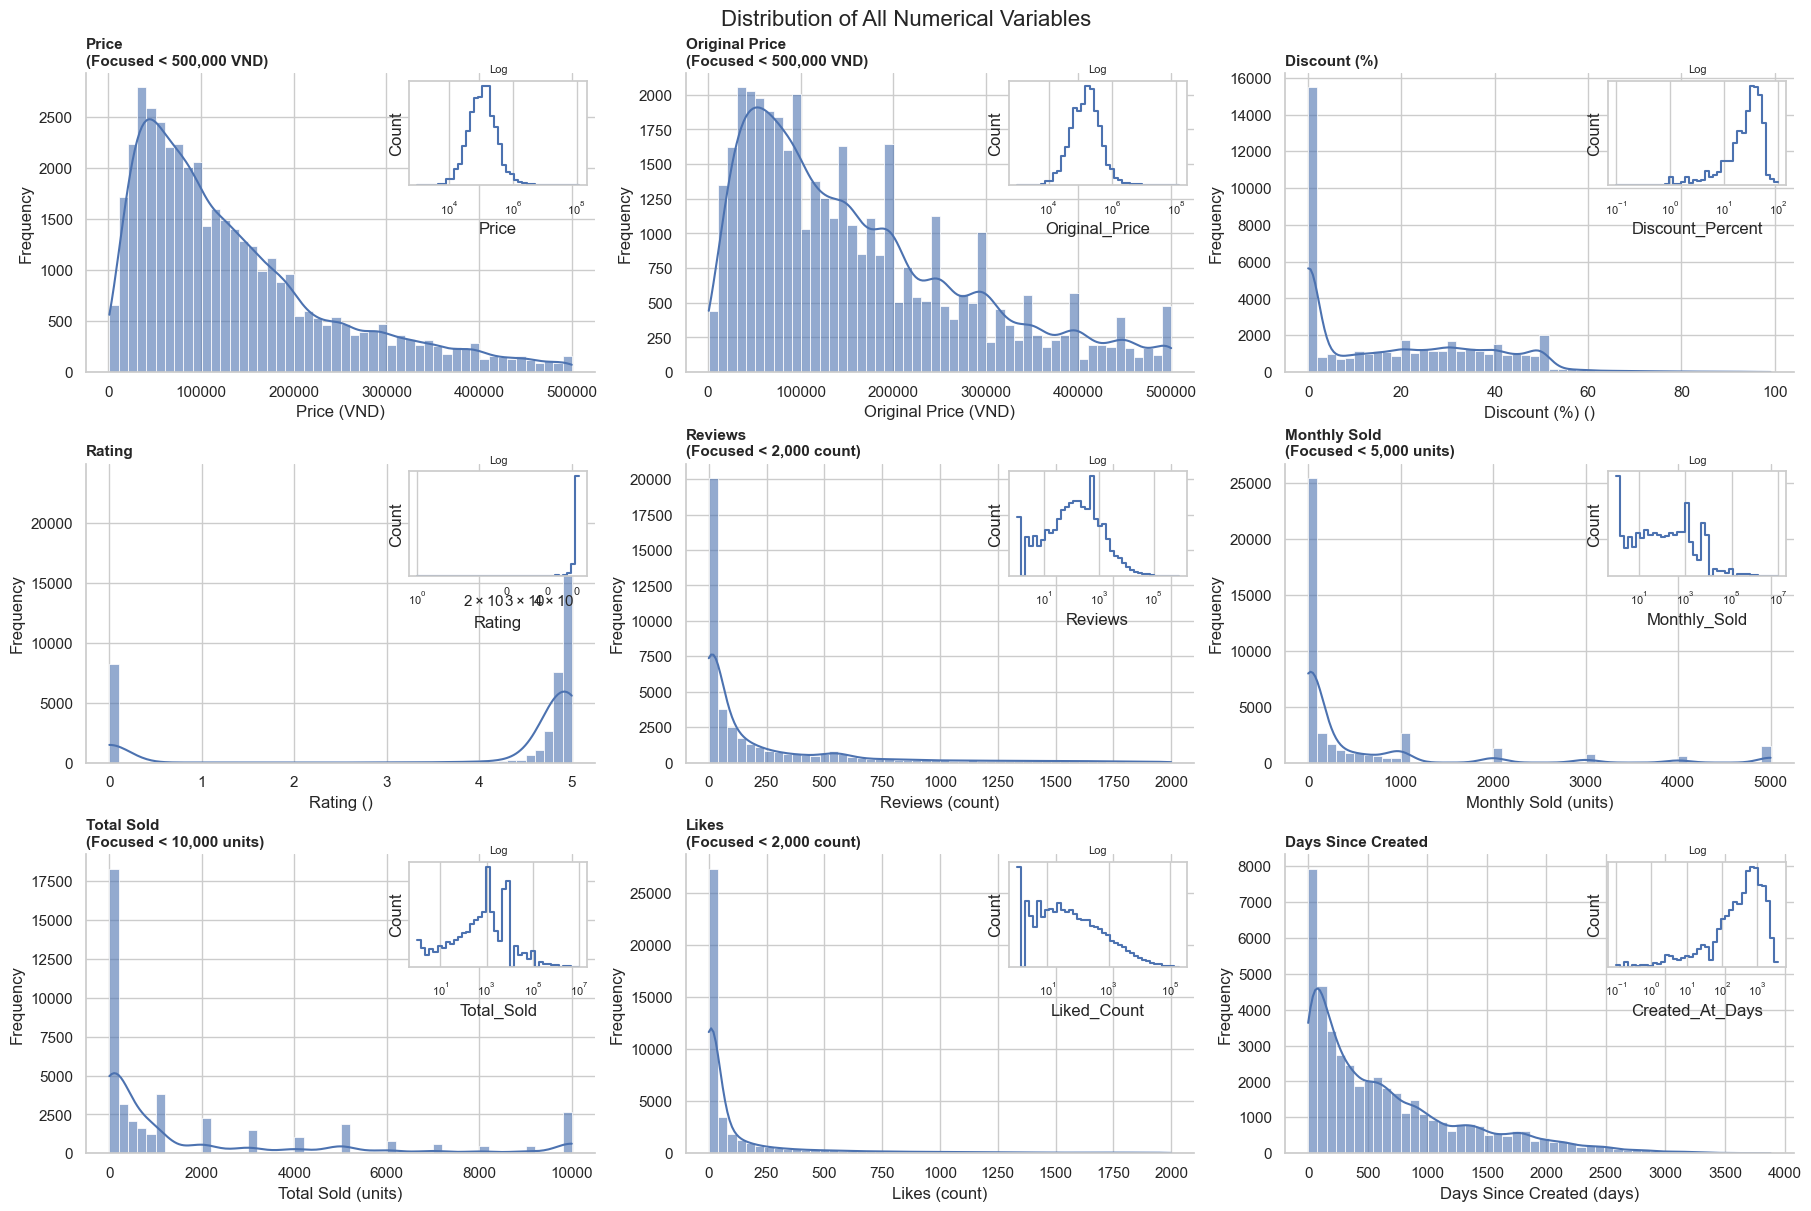

In [24]:
tmp = df_num.copy()

def plot_continuous_subplot(ax, col, title, limit=None, unit=""):
    data = tmp[col].dropna()

    # ===== MAIN DISTRIBUTION (có thể zoom nếu cần) =====
    if limit:
        data_plot = data[data <= limit]
        ax.set_title(f"{title}\n(Focused < {limit:,.0f} {unit})", fontsize=11, weight='bold', loc='left')
    else:
        data_plot = data
        ax.set_title(f"{title}", fontsize=11, weight='bold', loc='left')

    sns.histplot(data_plot, bins=50, kde=True, alpha=0.6, ax=ax)

    ax.set_xlabel(f"{title} ({unit})")
    ax.set_ylabel("Frequency")
    sns.despine(ax=ax)

    # ===== INSET LOG SCALE (cho skew) =====
    ax_ins = inset_axes(ax, width="35%", height="35%", loc='upper right')
    sns.histplot(data, bins=40, ax=ax_ins, log_scale=True, element="step", fill=False)

    ax_ins.set_title("Log", fontsize=8)
    ax_ins.set_yticks([])
    ax_ins.tick_params(axis='x', labelsize=8)


# ===== CONFIG ALL NUMERICAL =====
configs = [
    ('Price', 'Price', 500000, 'VND'),
    ('Original_Price', 'Original Price', 500000, 'VND'),
    ('Discount_Percent', 'Discount (%)', None, ''),
    ('Rating', 'Rating', None, ''),
    ('Reviews', 'Reviews', 2000, 'count'),
    ('Monthly_Sold', 'Monthly Sold', 5000, 'units'),
    ('Total_Sold', 'Total Sold', 10000, 'units'),
    ('Liked_Count', 'Likes', 2000, 'count'),
    ('Created_At_Days', 'Days Since Created', None, 'days')
]

# ===== PLOT =====
fig, axes = plt.subplots(3, 3, figsize=(18, 12), constrained_layout=True)
fig.suptitle('Distribution of All Numerical Variables', fontsize=16)

for ax, (col, title, limit, unit) in zip(axes.flatten(), configs):
    plot_continuous_subplot(ax, col, title, limit, unit)

plt.show()

# 3. Categorical (Multi-class) Column Analysis

| Column            | Current Dtype | Example Value | Target Dtype | Meaning / Description                            |
| :---------------- | :------------ | :------------ | :----------- | :----------------------------------------------- |
| **Platform**      | Object        | `Shopee`      | Category     | E-commerce platform where the product is listed  |
| **Main_Category** | Object        | `Beauty`      | Category     | Main product category (high-level grouping)      |
| **Sub_Category**  | Object        | `Skincare`    | Category     | Detailed product category                        |
| **Brand**         | Object        | `L'Oreal`     | Category     | Brand of the product                             |
| **Shop_Location** | Object        | `Hanoi`       | Category     | Location of the shop                             |

## 3.1 Overview information

In [28]:
categorical_cols = [
    'Platform',
    'Main_Category',
    'Sub_Category',
    'Brand',
    'Shop_Location'
]

df_cat = df[categorical_cols].copy()

df_cat.describe(include='object')

,Platform,Main_Category,Sub_Category,Brand,Shop_Location
count,45104,45104,45104,45104,45104
unique,1,8,63,3938,96
top,Shopee,Skin Care,kem tạo kiểu tóc,No Brand,Hà Nội
freq,45104,11178,939,19099,14788


## 3.2 Distribution

We take a look at the top-10 distribution of every attributes:
- ``Platform``: Shopee is the only value which makes sense since Shopee is the platform we choose to crawl
- ``Main_Category``: There are 8 categories in total including Skin Care, Hair Care, Makeup, Beauty Devices, Body Care, Oral Care, Fragrance, Dermocosmetics.
- ``Sub_Category``: There are 63 unique in total
- ``Brand``: Most of the brand is No brand which means they ae unidentified. We plan to drop this entirely!
- ``Shop_Location``: There are 96 in total. Some of them are inconsistent for example: TP. Hồ Chí Minh and Thành phố Hồ Chí Minh. We need to fix that in the next preprocessing progress.

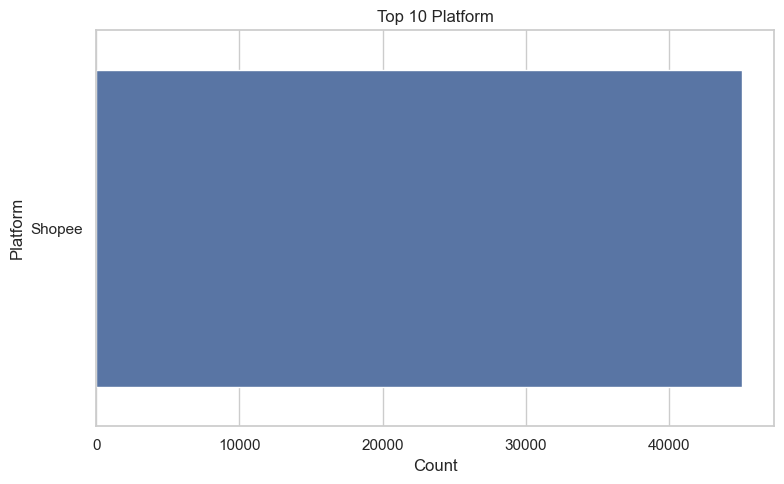

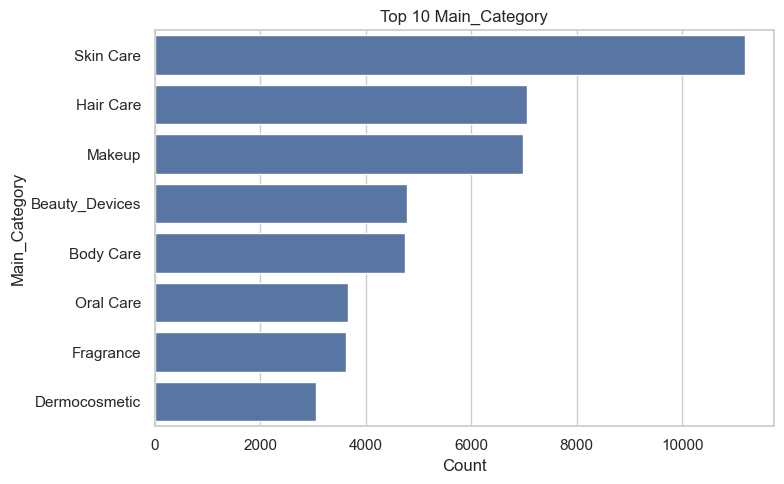

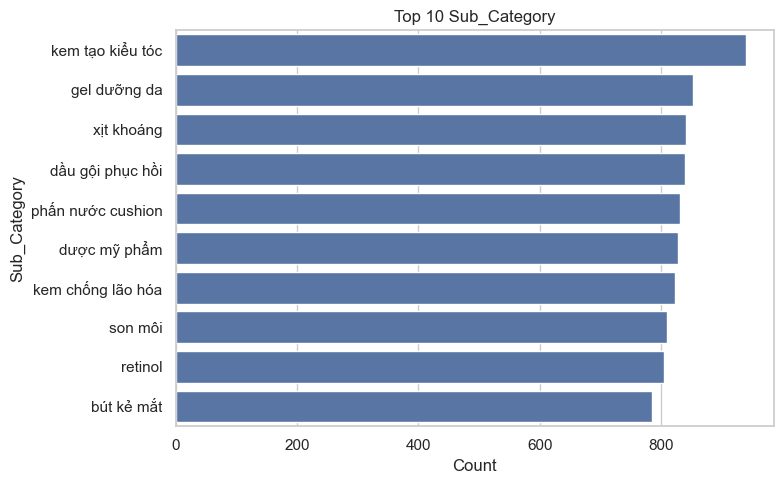

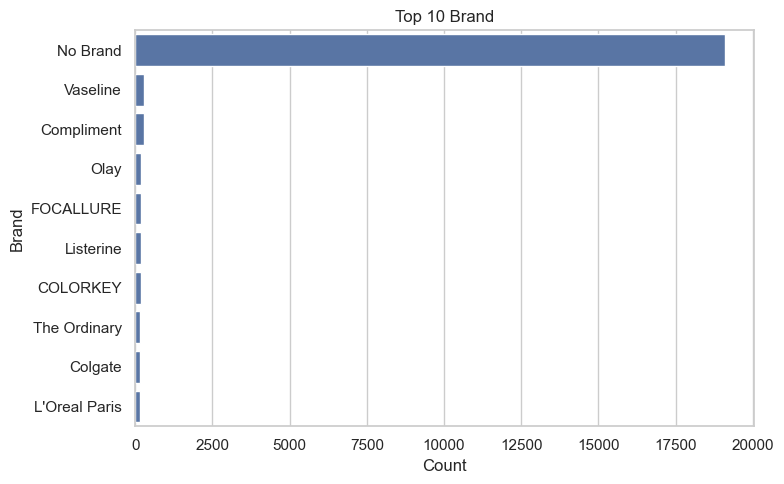

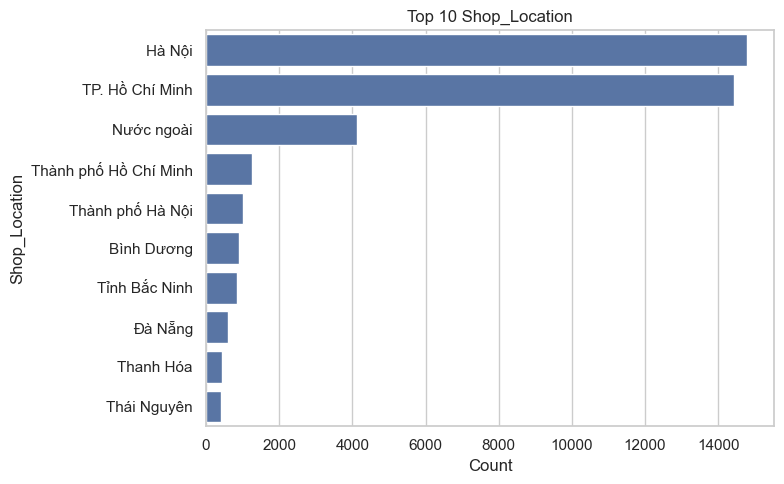

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

df_cat = df[categorical_cols].copy()

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    
    top10 = df_cat[col].value_counts().nlargest(10)
    
    sns.barplot(
        x=top10.values,
        y=top10.index
    )
    
    plt.title(f"Top 10 {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

## 3.3 Data Consistency

As mentioned above, ``Shop_Location`` is the most inconsistent attribute within the entire dataset. There are so many duplicated provinces such as: TP. Hồ Chí Minh & Thành phố Hồ Chí Minh. We will list out the entire distinct value of this column to see other duplication while sketching plans to reunite those typos:

Also the **BIG PROBLEM** is those provinces are the old ones. Viet Nam used to have 63 provinces while now there are 34 official provinces. We have to convert those provinces to make sure everything matches 

Our plan is to make consistent transformation:
- The term "TP." -> "Thành phố"
- Merge other countries' name with "Nước ngoài" 
- Add "Tỉnh" to province name
- There is also an empty string "", we will remove that
- We also need to pay attention to "Thừa Thiên Huế" and "Thành phố Huế"

In [33]:
pd.set_option('display.max_rows', None)
print(df_cat["Shop_Location"].value_counts())

Shop_Location
Hà Nội                   14788
TP. Hồ Chí Minh          14429
Nước ngoài                4120
Thành phố Hồ Chí Minh     1267
Thành phố Hà Nội          1023
Bình Dương                 906
Tỉnh Bắc Ninh              855
Đà Nẵng                    588
Thanh Hóa                  426
Thái Nguyên                418
Long An                    396
Đồng Nai                   362
Bắc Ninh                   362
Hàn Quốc                   357
Nam Định                   311
Hưng Yên                   250
Cần Thơ                    244
Tỉnh Tây Ninh              222
Hải Dương                  220
Hải Phòng                  185
Vĩnh Phúc                  185
                           167
Bắc Giang                  161
Lạng Sơn                   139
Đắk Lắk                    117
Quảng Ninh                 117
Thái Bình                  117
Thừa Thiên Huế             116
Hà Nam                     111
Quảng Nam                  104
Bến Tre                    102
Đồng Tháp                

# 4. Binary Column Analysis

| Column          | Current Dtype | Example Value | Target Dtype | Meaning / Description                            |
| :-------------- | :------------ | :------------ | :----------- | :----------------------------------------------- |
| **Is_Mall**     | Int64         | `1`           | Boolean      | Whether the shop is Shopee Mall (official store) |
| **Is_Verified** | Int64         | `1`           | Boolean      | Whether the shop is verified                     |
| **Is_FreeShip** | Int64         | `0`           | Boolean      | Whether product has free shipping                |
| **Is_Ads**      | Int64         | `1`           | Boolean      | Whether product is advertised                    |

We can see that in every binary attributes, negative value dominates

In [37]:
binary_cols = ['Is_Mall', 'Is_Verified', 'Is_FreeShip', 'Is_Ads']

df_bin = df[binary_cols].copy()

df_bin = df_bin.astype('bool')

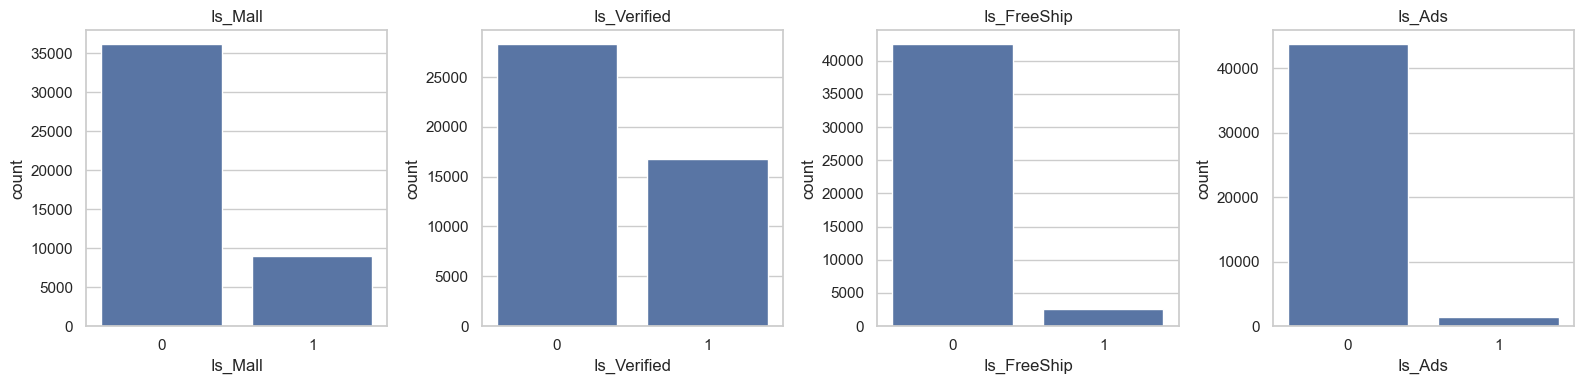

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, col in zip(axes, binary_cols):
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# 5. Summary

## Dataset Overview
- The dataset contains **45,104 products** with **21 attributes**, representing various aspects such as pricing, sales performance, customer engagement, and shop characteristics.
- Overall data quality is **good**, with **no duplicated or fully empty rows**.
- However, **inconsistencies exist in categorical variables**, especially in `Shop_Location`.

---

## Numerical Attribute
- Most numerical variables (e.g., `Price`, `Reviews`, `Monthly_Sold`, `Total_Sold`) are **highly right-skewed**, indicating:
  - A large number of low-performing products
  - A small number of **high-performing “bestsellers” dominating the market**
- `Rating` is **left-skewed**, with most values concentrated between **4.5 and 5.0**, reflecting a strong positive bias in user reviews.
- **Outliers are prevalent** across key variables, especially in sales and engagement metrics, which is expected in e-commerce data.
- Pricing insights:
  - Most products fall into the **affordable range (50,000–150,000 VND)**
  - Discounts commonly range from **20% to 50%**
  - A large portion of products have **no discount**

---

## Categorical Attribute
- The dataset includes:
  - **8 main categories** and **63 subcategories**
  - A large number of **"No Brand"** values, which may reduce analytical value
- `Shop_Location` is the most inconsistent column:
  - Contains **duplicate and inconsistent naming** (e.g., "TP. Hồ Chí Minh" vs "Thành phố Hồ Chí Minh")
  - Uses **outdated administrative divisions (63 provinces vs. current 34)**
  - Requires **standardization during preprocessing**

---

## Binary Features Attribute
- Binary variables (`Is_Mall`, `Is_Verified`, `Is_FreeShip`, `Is_Ads`) are **imbalanced**, with negative values dominating:
  - Most products are **not advertised**
  - Most are **not from Shopee Mall**
  - Most do **not offer free shipping**
- This suggests that the majority of products come from **small or independent sellers**